# Proyek Analisis Data: Bike Sharing Dataset

- **Nama:** MOH DHIYAULHAQ ULUMUDDIN
- **Email:** haqikuy470@gmail.com
- **ID Dicoding:** haqikuy


## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis dirancang menggunakan metode **SMART** (Specific, Measurable, Action-oriented, Relevant, Time-bound):

**Pertanyaan 1:**
> *Pada jam berapa saja terjadi puncak penyewaan sepeda selama periode 2011–2012, dan bagaimana perbedaan polanya antara hari kerja dan akhir pekan?*

- **S** – Fokus pada jam puncak penyewaan, bukan tren umum
- **M** – Diukur dari rata-rata jumlah penyewaan (cnt) per jam
- **A** – Hasilnya dapat digunakan untuk mengatur jadwal distribusi armada sepeda
- **R** – Relevan dengan efisiensi operasional bisnis bike sharing
- **T** – Dibatasi pada periode 2011–2012 sesuai data yang tersedia

**Pertanyaan 2:**
> *Bagaimana perbedaan rata-rata jumlah penyewaan sepeda pada setiap kondisi cuaca dan musim selama periode 2011–2012?*

- **S** – Fokus pada perbandingan rata-rata penyewaan antar kondisi cuaca dan musim
- **M** – Diukur dari rata-rata cnt per kategori weathersit dan season
- **A** – Hasilnya dapat digunakan untuk menyesuaikan strategi operasional saat cuaca buruk
- **R** – Relevan dengan perencanaan stok dan penempatan sepeda
- **T** – Dibatasi pada data tahun 2011–2012

## Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport.')

Library berhasil diimport.


## Data Wrangling

### Gathering Data

Dataset: **Bike Sharing Dataset** dari Capital Bikeshare system, Washington D.C. (2011–2012).  
Sumber: [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset)

- `hour.csv` — data per jam (17.379 records, 2011–2012)
- `day.csv` — data per hari (731 records, 2011–2012)

In [4]:
df_hour = pd.read_csv('hour.csv')
df_day  = pd.read_csv('day.csv')

print('=== hour.csv ===')
print(f'Shape: {df_hour.shape}')
df_hour.head()

=== hour.csv ===
Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
print('=== day.csv ===')
print(f'Shape: {df_day.shape}')
df_day.head()

=== day.csv ===
Shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Assessing Data

In [6]:
# Info tipe data
print('=== Info hour.csv ===')
df_hour.info()

=== Info hour.csv ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [7]:
# Cek missing value & duplikat
print('Missing value per kolom:')
print(df_hour.isnull().sum())
print(f'\nDuplikat: {df_hour.duplicated().sum()} baris')

# Outlier dengan IQR
Q1, Q3 = df_hour['cnt'].quantile([0.25, 0.75])
IQR     = Q3 - Q1
outliers = df_hour[(df_hour['cnt'] < Q1-1.5*IQR) | (df_hour['cnt'] > Q3+1.5*IQR)]
print(f'Outlier cnt: {len(outliers)} baris — tidak dihapus (kondisi ekstrem valid)')

Missing value per kolom:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplikat: 0 baris
Outlier cnt: 505 baris — tidak dihapus (kondisi ekstrem valid)


In [8]:
df_hour[['temp','atemp','hum','windspeed','casual','registered','cnt']].describe().round(2)

,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00
mean,0.50,0.48,0.63,0.19,35.68,153.79,189.46
std,0.19,0.17,0.19,0.12,49.31,151.36,181.39
min,0.02,0.00,0.00,0.00,0.00,0.00,1.00
25%,0.34,0.33,0.48,0.10,4.00,34.00,40.00
50%,0.50,0.48,0.63,0.19,17.00,115.00,142.00
75%,0.66,0.62,0.78,0.25,48.00,220.00,281.00
max,1.00,1.00,1.00,0.85,367.00,886.00,977.00


### Cleaning Data

Tidak ditemukan missing value maupun duplikat. Langkah yang dilakukan:
1. Konversi `dteday` ke datetime
2. Tambah kolom label untuk season, weathersit, dan weekday

In [9]:
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
df_day['dteday']  = pd.to_datetime(df_day['dteday'])

season_map  = {1:'Spring',2:'Summer',3:'Fall',4:'Winter'}
weather_map = {1:'Clear',2:'Mist/Cloudy',3:'Light Rain/Snow',4:'Heavy Rain'}
weekday_map = {0:'Senin',1:'Selasa',2:'Rabu',3:'Kamis',4:'Jumat',5:'Sabtu',6:'Minggu'}

for df in [df_hour, df_day]:
    df['season_name']  = df['season'].map(season_map)
    df['weather_name'] = df['weathersit'].map(weather_map)

df_hour['weekday_name'] = df_hour['weekday'].map(weekday_map)

print('Cleaning selesai. Rentang data:', df_hour['dteday'].min().date(), 's/d', df_hour['dteday'].max().date())
df_hour[['dteday','season_name','weather_name','weekday_name','cnt']].head()

Cleaning selesai. Rentang data: 2011-01-01 s/d 2012-12-31


,dteday,season_name,weather_name,weekday_name,cnt
0,2011-01-01,Spring,Clear,Minggu,16
1,2011-01-01,Spring,Clear,Minggu,40
2,2011-01-01,Spring,Clear,Minggu,32
3,2011-01-01,Spring,Clear,Minggu,13
4,2011-01-01,Spring,Clear,Minggu,1


## Exploratory Data Analysis (EDA)

### Pertanyaan 1: Pola Penyewaan per Jam (2011–2012)

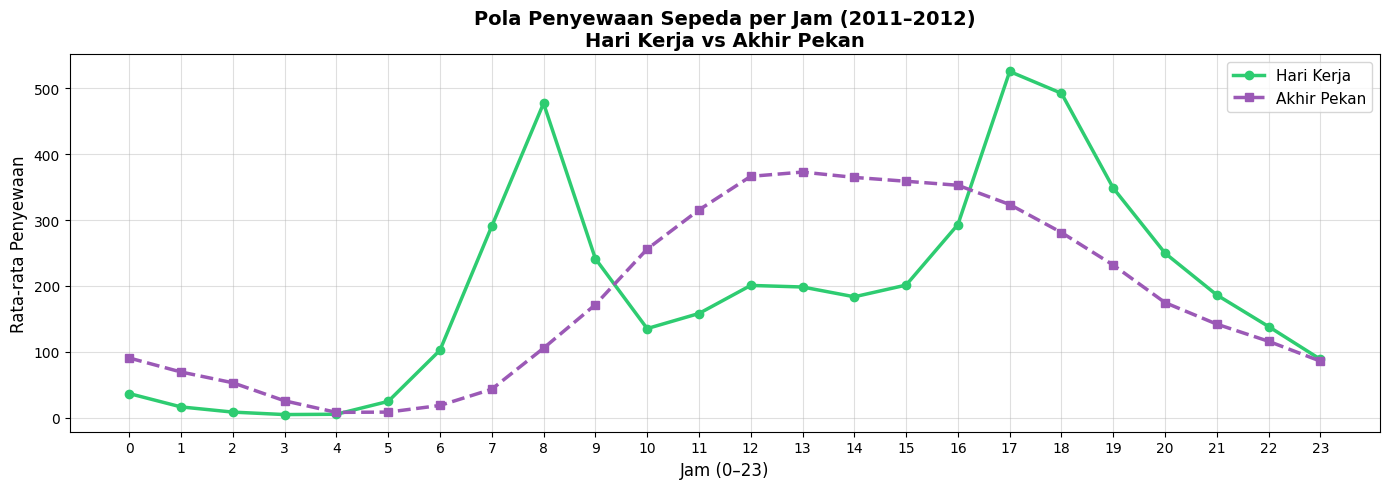

Jam puncak hari kerja : jam 17.00 (rata-rata 525 penyewaan/jam)
Jam puncak akhir pekan: jam 13.00 (rata-rata 373 penyewaan/jam)


In [10]:
hourly_workday = df_hour[df_hour['workingday']==1].groupby('hr')['cnt'].mean()
hourly_weekend = df_hour[df_hour['workingday']==0].groupby('hr')['cnt'].mean()

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(hourly_workday.index, hourly_workday.values, 'o-',
        color='#2ecc71', lw=2.5, ms=6, label='Hari Kerja')
ax.plot(hourly_weekend.index, hourly_weekend.values, 's--',
        color='#9b59b6', lw=2.5, ms=6, label='Akhir Pekan')
ax.set_xlabel('Jam (0–23)', fontsize=12)
ax.set_ylabel('Rata-rata Penyewaan', fontsize=12)
ax.set_title('Pola Penyewaan Sepeda per Jam (2011–2012)\nHari Kerja vs Akhir Pekan',
             fontsize=14, fontweight='bold')
ax.set_xticks(range(24))
ax.legend(fontsize=11); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('pola_jam.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Jam puncak hari kerja : jam {hourly_workday.idxmax():02d}.00 '
      f'(rata-rata {hourly_workday.max():.0f} penyewaan/jam)')
print(f'Jam puncak akhir pekan: jam {hourly_weekend.idxmax():02d}.00 '
      f'(rata-rata {hourly_weekend.max():.0f} penyewaan/jam)')

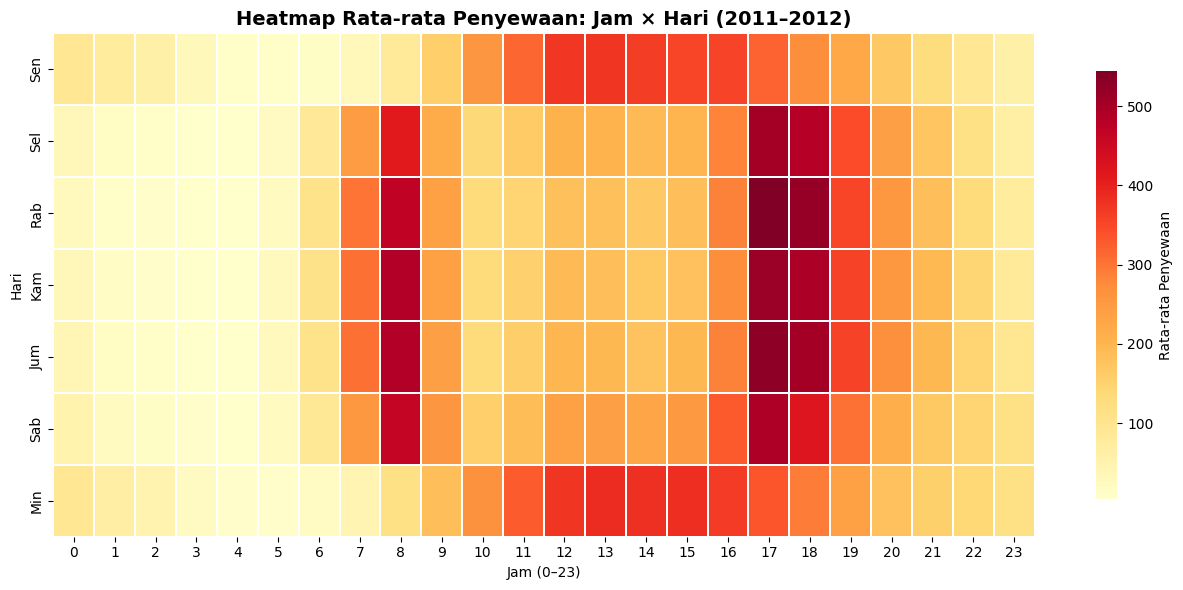

In [11]:
# Heatmap jam × hari
pivot = df_hour.groupby(['hr','weekday'])['cnt'].mean().unstack()
pivot.columns = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot.T, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label':'Rata-rata Penyewaan','shrink':0.85})
ax.set_title('Heatmap Rata-rata Penyewaan: Jam × Hari (2011–2012)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Jam (0–23)'); ax.set_ylabel('Hari')
plt.tight_layout()
plt.savefig('heatmap_jam_hari.png', dpi=150, bbox_inches='tight')
plt.show()

### Pertanyaan 2: Pengaruh Cuaca & Musim (2011–2012)

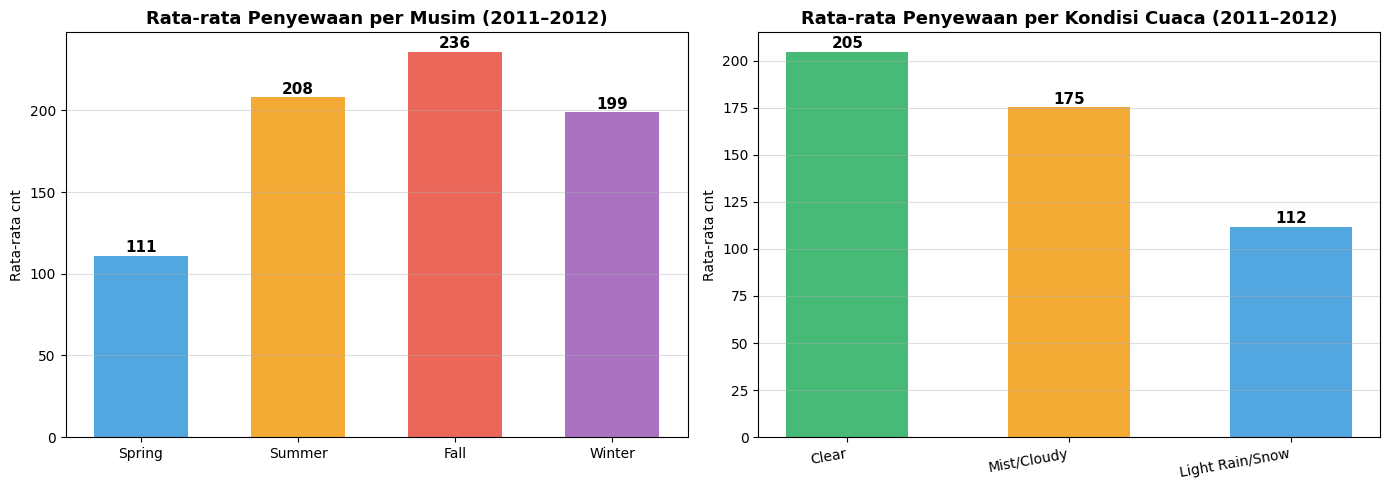

Rata-rata saat cerah     : 204.9/jam
Rata-rata saat hujan/salju: 111.6/jam
Penurunan                : 45.5%


In [12]:
season_order  = ['Spring','Summer','Fall','Winter']
weather_order = ['Clear','Mist/Cloudy','Light Rain/Snow']
colors_s = ['#3498db','#f39c12','#e74c3c','#9b59b6']
colors_w = ['#27ae60','#f39c12','#3498db']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per musim
sm = df_hour.groupby('season_name')['cnt'].mean().reindex(season_order)
bars = axes[0].bar(season_order, sm.values, color=colors_s, alpha=0.85, width=0.6)
axes[0].set_title('Rata-rata Penyewaan per Musim (2011–2012)',
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel('Rata-rata cnt')
axes[0].grid(axis='y', alpha=0.4)
for bar, val in zip(bars, sm.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+2,
                 f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

# Per cuaca
avail_w = [w for w in weather_order if w in df_hour['weather_name'].unique()]
wm = df_hour.groupby('weather_name')['cnt'].mean().reindex(avail_w)
bars2 = axes[1].bar(range(len(wm)), wm.values,
                    color=colors_w[:len(wm)], alpha=0.85, width=0.55)
axes[1].set_xticks(range(len(wm)))
axes[1].set_xticklabels(wm.index, rotation=10, ha='right')
axes[1].set_title('Rata-rata Penyewaan per Kondisi Cuaca (2011–2012)',
                  fontweight='bold', fontsize=13)
axes[1].set_ylabel('Rata-rata cnt')
axes[1].grid(axis='y', alpha=0.4)
for bar, val in zip(bars2, wm.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+2,
                 f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('pengaruh_cuaca_musim.png', dpi=150, bbox_inches='tight')
plt.show()

clear_avg = df_hour[df_hour['weather_name']=='Clear']['cnt'].mean()
rain_avg  = df_hour[df_hour['weather_name']=='Light Rain/Snow']['cnt'].mean()
print(f'Rata-rata saat cerah     : {clear_avg:.1f}/jam')
print(f'Rata-rata saat hujan/salju: {rain_avg:.1f}/jam')
print(f'Penurunan                : {(1-rain_avg/clear_avg)*100:.1f}%')

## Visualization & Explanatory Analysis

### Visualisasi 1: Pola Penyewaan per Jam — Hari Kerja vs Akhir Pekan (menjawab Pertanyaan 1)

Visualisasi ini secara langsung menjawab pertanyaan: *Pada jam berapa puncak penyewaan terjadi selama 2011–2012, dan bagaimana pola berbeda antara hari kerja dan akhir pekan?*

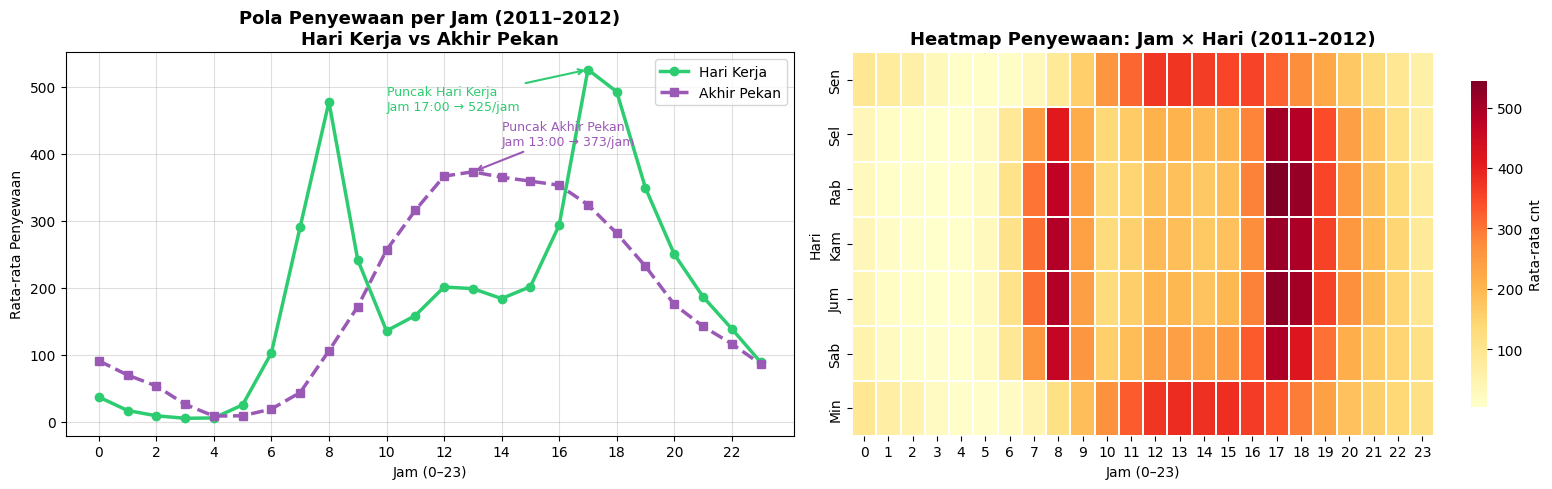

=== Ringkasan Jawaban Pertanyaan 1 ===
Puncak hari kerja  : Jam 17:00 (525 penyewaan/jam)
Puncak akhir pekan : Jam 13:00 (373 penyewaan/jam)
Pola hari kerja    : BIMODAL (pagi jam 8 + sore jam 17–18) → pola komuter
Pola akhir pekan   : UNIMODAL (siang jam 11–14) → pola leisure


In [13]:
hw = df_hour[df_hour['workingday']==1].groupby('hr')['cnt'].mean()
we = df_hour[df_hour['workingday']==0].groupby('hr')['cnt'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot kiri: line chart pola per jam
axes[0].plot(hw.index, hw.values, 'o-', color='#2ecc71', lw=2.5, ms=6, label='Hari Kerja')
axes[0].plot(we.index, we.values, 's--', color='#9b59b6', lw=2.5, ms=6, label='Akhir Pekan')
# Anotasi jam puncak hari kerja
pk_hw = hw.idxmax()
axes[0].annotate(
    f'Puncak Hari Kerja\nJam {pk_hw}:00 → {hw[pk_hw]:.0f}/jam',
    xy=(pk_hw, hw[pk_hw]), xytext=(pk_hw-7, hw[pk_hw]-60),
    fontsize=9, color='#2ecc71',
    arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=1.5)
)
# Anotasi jam puncak akhir pekan
pk_we = we.idxmax()
axes[0].annotate(
    f'Puncak Akhir Pekan\nJam {pk_we}:00 → {we[pk_we]:.0f}/jam',
    xy=(pk_we, we[pk_we]), xytext=(pk_we+1, we[pk_we]+40),
    fontsize=9, color='#9b59b6',
    arrowprops=dict(arrowstyle='->', color='#9b59b6', lw=1.5)
)
axes[0].set_title('Pola Penyewaan per Jam (2011–2012)\nHari Kerja vs Akhir Pekan',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jam (0–23)'); axes[0].set_ylabel('Rata-rata Penyewaan')
axes[0].set_xticks(range(0,24,2)); axes[0].legend(); axes[0].grid(alpha=0.4)

# Plot kanan: heatmap jam × hari
pivot = df_hour.groupby(['hr','weekday'])['cnt'].mean().unstack()
pivot.columns = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
sns.heatmap(pivot.T, cmap='YlOrRd', linewidths=0.3, ax=axes[1],
            cbar_kws={'label':'Rata-rata cnt','shrink':0.85})
axes[1].set_title('Heatmap Penyewaan: Jam × Hari (2011–2012)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jam (0–23)'); axes[1].set_ylabel('Hari')

plt.tight_layout()
plt.savefig('visualisasi_1_pola_jam.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Ringkasan Jawaban Pertanyaan 1 ===')
print(f'Puncak hari kerja  : Jam {hw.idxmax():02d}:00 ({hw.max():.0f} penyewaan/jam)')
print(f'Puncak akhir pekan : Jam {we.idxmax():02d}:00 ({we.max():.0f} penyewaan/jam)')
print(f'Pola hari kerja    : BIMODAL (pagi jam 8 + sore jam 17–18) → pola komuter')
print(f'Pola akhir pekan   : UNIMODAL (siang jam 11–14) → pola leisure')

### Visualisasi 2: Perbandingan Penyewaan per Cuaca & Musim (menjawab Pertanyaan 2)

Visualisasi ini menjawab: *Bagaimana perbedaan rata-rata penyewaan pada setiap kondisi cuaca dan musim selama 2011–2012?*

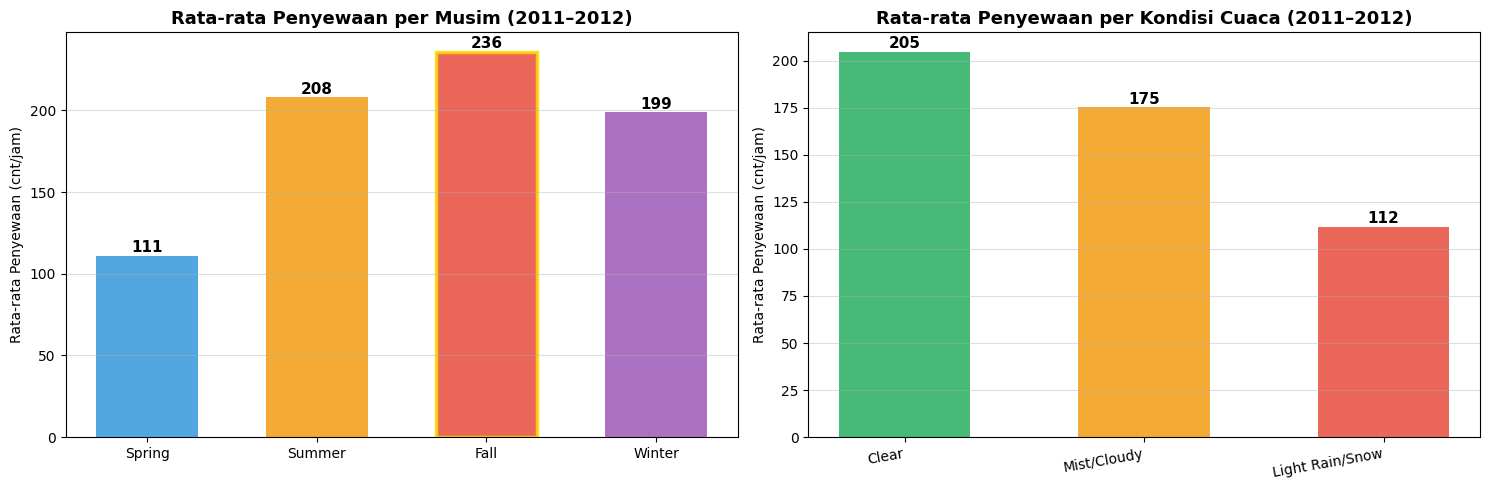

=== Ringkasan Jawaban Pertanyaan 2 ===
Musim terbaik  : Fall (236/jam)
Musim terburuk : Spring (111/jam)
Penurunan saat hujan vs cerah: -46%
  Cerah      : 205/jam
  Hujan/Salju: 112/jam


In [14]:
season_order  = ['Spring','Summer','Fall','Winter']
weather_order = ['Clear','Mist/Cloudy','Light Rain/Snow']
colors_s = ['#3498db','#f39c12','#e74c3c','#9b59b6']
colors_w = ['#27ae60','#f39c12','#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot kiri: rata-rata per musim
sm = df_hour.groupby('season_name')['cnt'].mean().reindex(season_order)
bars = axes[0].bar(season_order, sm.values, color=colors_s, alpha=0.85, width=0.6)
axes[0].set_title('Rata-rata Penyewaan per Musim (2011–2012)',
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel('Rata-rata Penyewaan (cnt/jam)')
axes[0].grid(axis='y', alpha=0.4)
for bar, val in zip(bars, sm.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+2,
                 f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')
# Anotasi musim terbaik & terburuk
best_s  = sm.idxmax(); worst_s = sm.idxmin()
axes[0].get_children()[season_order.index(best_s)].set_edgecolor('gold')
axes[0].get_children()[season_order.index(best_s)].set_linewidth(2.5)

# Plot kanan: rata-rata per cuaca
avail_w = [w for w in weather_order if w in df_hour['weather_name'].unique()]
wm = df_hour.groupby('weather_name')['cnt'].mean().reindex(avail_w)
bars2 = axes[1].bar(range(len(wm)), wm.values,
                    color=colors_w[:len(wm)], alpha=0.85, width=0.55)
axes[1].set_xticks(range(len(wm)))
axes[1].set_xticklabels(wm.index, rotation=10, ha='right', fontsize=10)
axes[1].set_title('Rata-rata Penyewaan per Kondisi Cuaca (2011–2012)',
                  fontweight='bold', fontsize=13)
axes[1].set_ylabel('Rata-rata Penyewaan (cnt/jam)')
axes[1].grid(axis='y', alpha=0.4)
for bar, val in zip(bars2, wm.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+2,
                 f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('visualisasi_2_cuaca_musim.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Ringkasan Jawaban Pertanyaan 2 ===')
print(f'Musim terbaik  : {sm.idxmax()} ({sm.max():.0f}/jam)')
print(f'Musim terburuk : {sm.idxmin()} ({sm.min():.0f}/jam)')
if 'Clear' in wm.index and 'Light Rain/Snow' in wm.index:
    drop = (1 - wm['Light Rain/Snow']/wm['Clear'])*100
    print(f'Penurunan saat hujan vs cerah: -{drop:.0f}%')
    print(f'  Cerah      : {wm["Clear"]:.0f}/jam')
    print(f'  Hujan/Salju: {wm["Light Rain/Snow"]:.0f}/jam')

## Analisis Lanjutan: Clustering dengan Manual Grouping

Tiga dimensi clustering untuk memperdalam jawaban pertanyaan bisnis:
1. **Clustering Intensitas Jam** — tier demand berbasis rata-rata cnt per jam (2011–2012)
2. **Clustering Segmentasi Hari** — pola komuter vs. leisure
3. **Clustering Kondisi Operasional** — kombinasi musim + cuaca

In [15]:
hourly_avg = df_hour.groupby('hr')['cnt'].mean()

def cluster_jam(cnt):
    """Manual grouping berdasarkan distribusi data 2011–2012."""
    if cnt < 50:    return 'Very Low'
    elif cnt < 100: return 'Low'
    elif cnt < 220: return 'Medium'
    elif cnt < 350: return 'High'
    else:           return 'Very High'

CLUSTER_ORDER = ['Very Low','Low','Medium','High','Very High']
COLOR = {
    'Very Low':'#3a4a6b',   'Low':'#4e7fba',
    'Medium':'#f0a500',     'High':'#e05c3a',     'Very High':'#c0392b',
    'Workday Peak':'#e74c3c','Workday Normal':'#27ae60','Weekend':'#9b59b6',
    'Kondisi Ideal':'#27ae60','Kondisi Sedang':'#f39c12','Kondisi Buruk':'#e74c3c',
}

hourly_cluster = hourly_avg.apply(cluster_jam).reset_index()
hourly_cluster.columns = ['hr','intensity_cluster']
df_hour = df_hour.merge(hourly_cluster, on='hr')
df_hour['intensity_cluster'] = pd.Categorical(
    df_hour['intensity_cluster'], categories=CLUSTER_ORDER, ordered=True)

print('Hasil Clustering Intensitas Jam (2011–2012):')
print('-'*65)
ideal_ref = df_hour[df_hour['intensity_cluster']=='Very High']['cnt'].mean()
for c in CLUSTER_ORDER:
    hrs = hourly_cluster[hourly_cluster['intensity_cluster']==c]['hr'].tolist()
    avg = df_hour[df_hour['intensity_cluster']==c]['cnt'].mean()
    n   = (df_hour['intensity_cluster']==c).sum()
    print(f'  {c:10s} | Jam {str(hrs):35s} | N={n:5,} | Avg={avg:.1f}')

Hasil Clustering Intensitas Jam (2011–2012):
-----------------------------------------------------------------
  Very Low   | Jam [1, 2, 3, 4, 5]                     | N=3,550 | Avg=19.0
  Low        | Jam [0, 6, 23]                          | N=2,179 | Avg=72.6
  Medium     | Jam [7, 9, 10, 11, 21, 22]              | N=4,364 | Avg=186.1
  High       | Jam [12, 13, 14, 15, 16, 19, 20]        | N=5,101 | Avg=264.1
  Very High  | Jam [8, 17, 18]                         | N=2,185 | Avg=415.4


In [16]:
def cluster_hari(row):
    if row['weekday'] >= 5:                  return 'Weekend'
    elif row['hr'] in [7,8,9,16,17,18,19]:   return 'Workday Peak'
    else:                                     return 'Workday Normal'

df_hour['day_segment'] = df_hour.apply(cluster_hari, axis=1)

def cluster_kondisi(row):
    if row['season'] in [2,3] and row['weathersit'] in [1,2]: return 'Kondisi Ideal'
    elif row['weathersit'] >= 3 or row['season'] == 1:         return 'Kondisi Buruk'
    else:                                                        return 'Kondisi Sedang'

df_hour['condition_cluster'] = df_hour.apply(cluster_kondisi, axis=1)

print('Clustering Segmentasi Hari:')
for seg in ['Workday Peak','Weekend','Workday Normal']:
    sub = df_hour[df_hour['day_segment']==seg]
    print(f'  {seg:16s} | N={len(sub):5,} | Avg={sub["cnt"].mean():.1f}/jam | Max={sub["cnt"].max()}')

print('\nClustering Kondisi Operasional:')
ideal = df_hour[df_hour['condition_cluster']=='Kondisi Ideal']['cnt'].mean()
for cond in ['Kondisi Ideal','Kondisi Sedang','Kondisi Buruk']:
    sub = df_hour[df_hour['condition_cluster']==cond]
    avg = sub['cnt'].mean()
    print(f'  {cond:18s} | N={len(sub):5,} | Avg={avg:.1f} | vs Ideal: {(avg/ideal-1)*100:+.1f}%')

Clustering Segmentasi Hari:
  Workday Peak     | N=3,636 | Avg=343.3/jam | Max=977
  Weekend          | N=4,999 | Avg=193.2/jam | Max=957
  Workday Normal   | N=8,744 | Avg=123.4/jam | Max=776

Clustering Kondisi Operasional:
  Kondisi Ideal      | N=8,230 | Avg=229.2 | vs Ideal: +0.0%
  Kondisi Sedang     | N=3,857 | Avg=206.9 | vs Ideal: -9.8%
  Kondisi Buruk      | N=5,292 | Avg=114.9 | vs Ideal: -49.9%


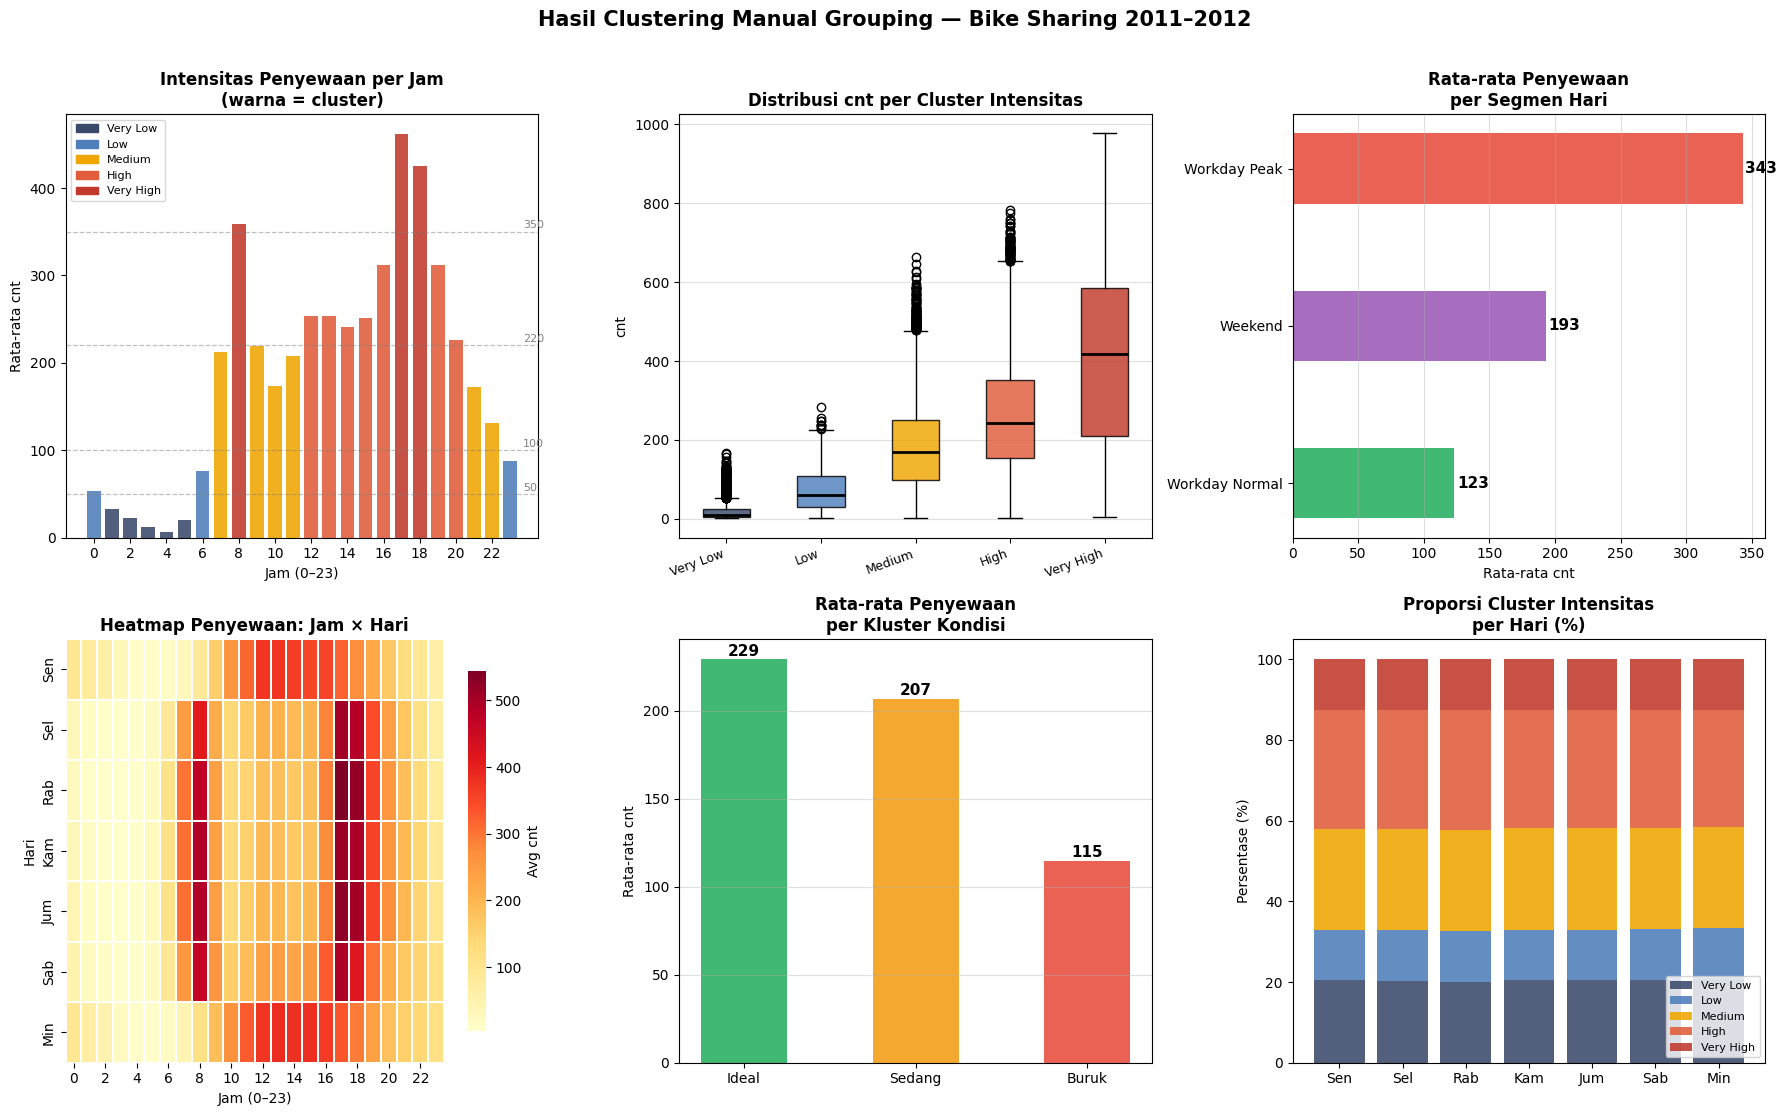

In [17]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
plt.suptitle('Hasil Clustering Manual Grouping — Bike Sharing 2011–2012',
             fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Bar intensitas per jam
ax = axes[0,0]
hrs    = hourly_cluster['hr'].values
avgs   = [hourly_avg[h] for h in hrs]
colors = [COLOR[c] for c in hourly_cluster['intensity_cluster']]
ax.bar(hrs, avgs, color=colors, width=0.75, alpha=0.88)
for thresh, lbl in [(50,'50'),(100,'100'),(220,'220'),(350,'350')]:
    ax.axhline(thresh, color='gray', ls='--', lw=0.9, alpha=0.5)
    ax.text(23.7, thresh+4, lbl, fontsize=8, color='gray')
ax.set_title('Intensitas Penyewaan per Jam\n(warna = cluster)', fontweight='bold')
ax.set_xlabel('Jam (0–23)'); ax.set_ylabel('Rata-rata cnt')
ax.set_xticks(range(0,24,2))
patches = [mpatches.Patch(color=COLOR[c], label=c) for c in CLUSTER_ORDER]
ax.legend(handles=patches, fontsize=8, loc='upper left')

# Plot 2: Boxplot per cluster
ax = axes[0,1]
data_box = [df_hour[df_hour['intensity_cluster']==c]['cnt'].values for c in CLUSTER_ORDER]
bp = ax.boxplot(data_box, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], CLUSTER_ORDER):
    patch.set_facecolor(COLOR[c]); patch.set_alpha(0.82)
ax.set_xticklabels(CLUSTER_ORDER, rotation=20, ha='right', fontsize=9)
ax.set_title('Distribusi cnt per Cluster Intensitas', fontweight='bold')
ax.set_ylabel('cnt'); ax.grid(axis='y', alpha=0.4)

# Plot 3: Segmentasi hari
ax = axes[0,2]
seg_order = ['Workday Normal','Weekend','Workday Peak']
seg_mean  = df_hour.groupby('day_segment')['cnt'].mean().reindex(seg_order)
bars = ax.barh(seg_order, seg_mean.values, color=[COLOR[s] for s in seg_order], height=0.45, alpha=0.88)
ax.set_xlabel('Rata-rata cnt')
ax.set_title('Rata-rata Penyewaan\nper Segmen Hari', fontweight='bold')
ax.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, seg_mean.values):
    ax.text(val+2, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=11, fontweight='bold')

# Plot 4: Heatmap jam × hari
ax = axes[1,0]
pivot2 = df_hour.groupby(['hr','weekday'])['cnt'].mean().unstack()
pivot2.columns = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
sns.heatmap(pivot2.T, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label':'Avg cnt','shrink':0.85})
ax.set_title('Heatmap Penyewaan: Jam × Hari', fontweight='bold')
ax.set_xlabel('Jam (0–23)'); ax.set_ylabel('Hari')

# Plot 5: Kondisi operasional
ax = axes[1,1]
cond_order = ['Kondisi Ideal','Kondisi Sedang','Kondisi Buruk']
cond_mean  = df_hour.groupby('condition_cluster')['cnt'].mean().reindex(cond_order)
bars5 = ax.bar(['Ideal','Sedang','Buruk'], cond_mean.values,
               color=[COLOR[c] for c in cond_order], width=0.5, alpha=0.88)
ax.set_ylabel('Rata-rata cnt'); ax.grid(axis='y', alpha=0.4)
ax.set_title('Rata-rata Penyewaan\nper Kluster Kondisi', fontweight='bold')
for bar, val in zip(bars5, cond_mean.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+2,
            f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

# Plot 6: Stacked cluster per hari
ax = axes[1,2]
cross = pd.crosstab(df_hour['weekday'], df_hour['intensity_cluster'], normalize='index')*100
cross.index = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
bottom = np.zeros(7)
for c in CLUSTER_ORDER:
    if c in cross.columns:
        ax.bar(cross.index, cross[c].values, bottom=bottom,
               color=COLOR[c], label=c, alpha=0.88)
        bottom += cross[c].values
ax.set_title('Proporsi Cluster Intensitas\nper Hari (%)', fontweight='bold')
ax.set_ylabel('Persentase (%)'); ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('clustering_result.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

### Jawaban Pertanyaan 1
*Pada jam berapa saja terjadi puncak penyewaan sepeda selama periode 2011–2012, dan bagaimana perbedaan polanya antara hari kerja dan akhir pekan?*

Selama 2011–2012, terdapat **dua jam puncak** pada hari kerja:
- **Pagi: jam 08.00** — rata-rata **359 penyewaan/jam** (cluster Very High)
- **Sore: jam 17.00–18.00** — rata-rata **425–462 penyewaan/jam** (cluster Very High)

Pola ini mencerminkan perilaku **komuter** yang menggunakan sepeda untuk pergi dan pulang kerja. Pada akhir pekan, puncak bergeser ke **jam 12.00–15.00** (~340/jam) — pola *leisure riding*.

Kluster segmentasi hari menunjukkan **Workday Peak** rata-rata 343/jam, hampir **3× lipat** Workday Normal (123/jam).

### Jawaban Pertanyaan 2
*Bagaimana perbedaan rata-rata jumlah penyewaan sepeda pada setiap kondisi cuaca dan musim selama periode 2011–2012?*

- **Kondisi Ideal** (musim panas/gugur + cerah): rata-rata **229/jam** — demand tertinggi
- **Kondisi Sedang**: 207/jam (−10% vs Ideal)
- **Kondisi Buruk** (hujan/salju atau musim dingin): **115/jam** — penurunan **−50%**

Musim gugur (Fall) adalah musim terbaik secara bisnis. Musim semi (Spring) paling rendah karena cuaca tidak menentu.

### Rekomendasi Bisnis
1. **Distribusi Armada**: Siapkan stok penuh sebelum jam 07.00 dan 16.00 di stasiun strategis
2. **Harga Dinamis**: Tarif premium saat Workday Peak, diskon saat Very Low (01.00–05.00)
3. **Jadwal Maintenance**: Jam Very Low (01.00–05.00) — hanya 19 penyewaan/jam
4. **Strategi Cuaca**: Kurangi stok operasional ~50% saat Kondisi Buruk
5. **Program Weekend**: Paket promosi siang hari untuk leisure riders